# 9.1 Introduction to multiple regression

---

#### Summary videos

- [Introduction to multiple regression](https://youtu.be/sQpAuyfEYZg?si=VxMLmUnFVN4zLwJB) (5 minutes)
- [Model selection in multiple regression](https://youtu.be/VB1qSwoF-l0?si=-Rrewl4GAzsR1b7x) (4 minutes)

---

**Multiple regression** is a way of extending our linear regression methods to cases where there are *several* predictor variables. With $k$ predictor variables, a multiple regression model will take the form

$$ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_k x_k. $$

Let's another look at the `loans` data from Chapters 1 and 2.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scipy.stats as stats
import pandas as pd
import statsmodels.api as sm
from plotnine import *

loans = pd.read_csv('https://raw.githubusercontent.com/clarkti5/math-209-data-sets/main/loans_full_schema.csv')
loans.head()

## Indicator variables and categorical variables as predictors

This dataset contains 10,000 loans and tracks 55 distinct variables on these loans. One of these variables is `public_record_bankrupt` which counts the number of bankruptcies the person has on file.

We'll create an indicator variable `bankruptcy` that takes a value of `1` if the person has any bankruptcies and a value of `0` otherwise. Then, let's see if this can be used to predict the `interest_rate` of the loan.

In [ ]:
loans['bankruptcy'] = loans['public_record_bankrupt'].apply(lambda x: 1 if x > 0 else 0)
loans[['bankruptcy', 'interest_rate']].head()

In [ ]:
(
    ggplot(loans) +
    aes(x = 'bankruptcy', y = 'interest_rate') +
    geom_point() +
    geom_smooth(method = 'lm', se = False)
)

In [ ]:
def least_squares_regression(data, response_variable, predictor_variable):
  formula_string = response_variable + " ~ " + predictor_variable
  model = sm.formula.ols(formula = formula_string, data = data)
  model_fitted = model.fit()

  print(model_fitted.summary())
  return model_fitted

In [ ]:
least_squares_regression(loans, 'interest_rate', 'bankruptcy')

### Exercise

- Write out the linear regression model for `interest_rate` as predicted by `bankruptcy`.
- Does the model suggest that `bankruptcy` is predictive of `interest_rate`?
- Interpret the slope of the model in context.
- How much of the variability in `interest_rate` is explained by `bankruptcy`?

#### Solution

- The linear regression model is

$$\hat{\texttt{interest_rate}} = 12.3380 + 0.7368 \cdot \texttt{bankruptcy}.$$

- Since the p-value on `bankruptcy` is $0.000$, the model suggests that `bankruptcy` is a statistically significant predictor of `interest_rate`.

- According to the model, having a bankruptcy on record results in an interest rate increase of $0.7368\%$ on average.

- We see $R^2 = 0.002$, so about $0.2\%$ of the variation in `intereste_rate` is explained by `bankruptcy`.

The variable `verified_income` is a categorical variable with 3 levels.

In [ ]:
loans['verified_income'].value_counts()

In [ ]:
least_squares_regression(loans, 'interest_rate', 'verified_income')

The output lists coefficients for 2 of the levels, but leaves out the `Not Verified` level. The missing level is called the **reference level** --- it is the level that the others are measured against.

### Exercise

- Does `verified_income` appear to be predictive of `interest_rate`?
- Write out the equation for linear model according to the summary above.
- How much variability in `interest_rate` is explained by `verified_income`?
- Use the model to find the average interest rate for borrowers whose income source and amount are both not verified.
- Use the model to find the average interest rate for borrowers whose income source is verified, but the amount is not.
- Interpret the coefficients in context.

#### Solution

- The p-values for the coefficients of `T.Source Verified` and `T.Verified` are both $0.000$, suggesting that `verified_income` is a statistically significant predictor of `interest_rate`.

- The model is
$$\hat{\texttt{interest_rate}} = 11.0995 + 1.4160 \cdot \texttt{T.Source Verified} + 3.2543 \cdot \texttt{T.Verified}.$$

- $R^2 = 0.059$, so about $5.9\%$ of the variation in `interest_rate` is explained by `verified_income`.

- If both source and amount are not verified, then we have `T. Source Verified` and `T.Verified` equal to $0$. In this case, the model predicts

$$\hat{\texttt{interest_rate}} = 11.0995\%.$$

- If the income source is verified but not the amount, then `T.Source Verified` is $1$ but `T.Verified` is 0. In this case the model predicts

$$\hat{\texttt{interest_rate}} = 11.0995 + 1.4160 \cdot 1 + 3.2543 \cdot 0 = 12.5155\%.$$

- **Intercept.** The average interest rate for borrowers whose income source and amount are not verified is $11.0995\%$.

- **T.Source Verified.** The model predicts that having the income source verified will increase the rate by $1.4160\%$ on average.

- **T.Verfied.** The model predicts that having both the income source and amount verified will increase the interest rate by $3.2543\%$ on average.

## Including and assessing many variables in a model

It may seem counterintuitive that having a verified income can increase the interest rate on a loan. However, there are many other variables at play, which leads us to consider **multiple regression** as a means of incorporating other features into our model.

We can build a linear model that uses the predictors
- `verified_income`
- `debt_to_income`
- `bankruptcy`
- `term`
- `issue_month`
- `months_since_last_credit_inquiry`.

In [ ]:
least_squares_regression(loans, 'interest_rate', 'verified_income + debt_to_income + bankruptcy + term + issue_month + months_since_last_credit_inquiry' )

### Exercise

- Write out the regression model from the output.
- Notice that `bankruptcy` has a different coefficient in this model than the simple regression model earlier. Why do you think that is?
- Do some of the predictors seem to do a *better job* than others?
- Pick an entry from `loans` and find the residual from the model.

#### Solution

- $$\hat{\texttt{interest_rate}} = 5.0592 + 1.0961\cdot\texttt{T.Source Verified} + 2.4808\cdot\texttt{T.Verified} - 0.0784\cdot\texttt{T.Jan-2018} - 0.1517\cdot\texttt{T.Mar-2018} + 0.0342\cdot\texttt{debt_to_income} + 0.5604\cdot\texttt{bankruptcy} + 0.1457\cdot\texttt{term} - 0.0631\cdot\texttt{months_since_last_credit_inquiry}.$$

- This model takes many other variables into consideration.

- The `issue_month` indicator variables have relatively large p-values, hence do not appear to be statistically significant predictors of `interest_rate`. All of the other variables have p-values of $0.000$.

In [ ]:
loans[['verified_income', 'debt_to_income', 'bankruptcy', 'term', 'issue_month', 'months_since_last_credit_inquiry', 'interest_rate']].iloc[23]

In [ ]:
# Predict the interest rate and find the residual
X = loans[['verified_income', 'debt_to_income', 'bankruptcy', 'term', 'issue_month', 'months_since_last_credit_inquiry']]

model = least_squares_regression(loans, 'interest_rate', 'verified_income + debt_to_income + bankruptcy + term + issue_month + months_since_last_credit_inquiry')

print("---")
print(f"Predicted interest rate: {model.predict(X)[23]}")
print(f"Actual interest rate: {loans['interest_rate'][23]}")
print(f"Residual: {loans['interest_rate'][23] - model.predict(X)[23]}")

## Collinearity

We can examine the correlations between some of the predictor variables to investigate any **collinearity**. Note that collinearity can interfere with the model's predictions and experiments are typically designed to avoid collinear predictors as much as possible.

In [ ]:
loans[['debt_to_income', 'bankruptcy', 'term', 'months_since_last_credit_inquiry']].corr()

## Adjusted R-squared

The usual $R^2$ value tends to be a little optimistic in the context of multiple linear regression. The **adjusted $R^2$** values corrects for this. See Section 9.1.3 on page 349 of the textbook for the details.


### Exercise

Examine the difference between $R^2$ and the adjusted $R^2$ values for each of the models above.

# 9.2 Model selection

The most complicated model is not always the best model. It is common to identify predictors in the **full model** that are not performing well and prune them, creating what is called a **parsimonious model**. Consider again the multiple regression model attempting to predict `interest_rate`.

In [ ]:
least_squares_regression(loans, 'interest_rate', 'verified_income + debt_to_income + bankruptcy + term + issue_month + months_since_last_credit_inquiry')

The `issue_month` variable has very large p-values. What happens if we remove it?

In [ ]:
least_squares_regression(loans, 'interest_rate', 'verified_income + debt_to_income + bankruptcy + term + months_since_last_credit_inquiry' )

### Question

Which of the two models seems to perform better?

```
Hint: Compare the adjusted R-squared values! A higher adjusted R-squared
value can be considered a better-performing model.
```

We just performed a **backward elimination** of the predictor variables using the **p-value** approach.

A similar approach drops variables one at a time and selects the resulting parsimonious model with the largest adjusted $R^2$ value. This is called **backward elimination with the adjusted $R^2$ appraoch**.

In [ ]:
# Drop a predictor variable, one at a time, and select the parsimonious model with largest adjusted
# R^2. You should end up with the following model.

least_squares_regression(loans, 'interest_rate',
                         'verified_income + debt_to_income + bankruptcy + term'
                         )

Here are some summaries from pages 355 and 356 of the textbook.

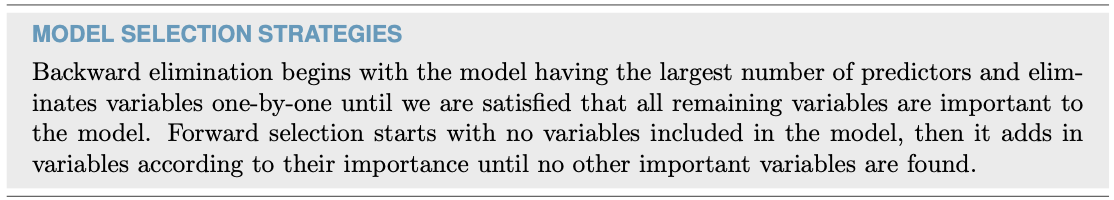

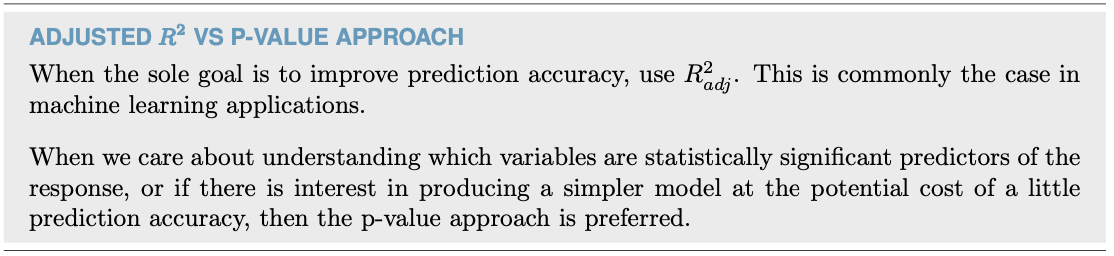

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.